# MindLens : Mental Health Text Classifier
### Built on Real Reddit Data · No Synthetic Samples

This notebook trains **MindLens**, a deep learning model that reads a piece of text and classifies it into one of five mental health categories

**Student Number:** A00080346

**Student Name:** Heli Pravinbhai Kuvadiya

**Module:** Deep Learning Application, MSc Data Science  




##  1. Install All Required Libraries

Run this cell first. It installs everything MindLens needs.  
You only need to run this **once per session** (or once ever if using a virtual env).



In [ ]:

!pip install jupyter torch torchvision transformers datasets \
    scikit-learn shap matplotlib seaborn vaderSentiment
!jupyter notebook

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 5.6 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.6/80.6 MB 6.2 MB/s eta 0:00:0000:0100:01
  Attempting uninstall: torch
    Found existing installation: torch 2.10.0
    Uninstalling torch-2.10.0:╸━━━━━━━━━━━━━━━━━ 4/7 [torch]
      Successfully uninstalled torch-2.10.00m━━━━━━━━━━━━━━━━━ 4/7 [torch]
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7/7 [isoduration] [torchvision]
[I 2026-04-13 16:12:56.142 ServerApp] Extension package aext_assistant took 0.5956s to import
[I 2026-04-13 16:12:56.150 ServerApp] ****************** ENVIRONMENT [Panels] Environment.PRODUCTION ******************
[I 2026-04-13 16:12:56.151 ServerApp] ****************** ENVIRONMENT [Panels] Environment.PRODUCTION ******************
[W 2026-04-13 16:12:56.204 ServerApp] Database not initialized by migration_upgrade(). Running it again
Database not initialized by migration_upgrade(). Running it again
[I 2026-04-13 16:12:56.204 ServerAp

In [2]:

# Install all Python packages needed for MindLens
# - torch / torchvision : the deep learning engine
# - transformers        : loads the RoBERTa language model from HuggingFace
# - datasets            : streams the Reddit mental-health dataset
# - scikit-learn        : splitting data, metrics (accuracy, F1, etc.)
# - vaderSentiment      : fast rule-based sentiment scorer (no GPU needed)
# - shap                : explains *why* the model made each prediction
# - matplotlib / seaborn: charts and confusion matrices
import sys
!{sys.executable} -m pip install transformers datasets scikit-learn vaderSentiment torch --quiet
print("✓ Dependencies installed")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 4.5 MB/s eta 0:00:00
✓ Dependencies installed


### 2. Imports & Global Settings

This cell loads every library and sets the key numbers that control how the model trains.  

In [3]:
import pandas as pd # DataFrames, think of it as Python's Excel
import numpy as np # Maths on arrays
import re # Regular expressions, used for text cleaning
from datasets import load_dataset # Streams HuggingFace datasets
from sklearn.model_selection import train_test_split        # Splits data into train/val/test
from sklearn.utils import resample                          # Up/down-samples class sizes
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer  # Sentiment scoring
from transformers import RobertaTokenizer                   # Converts text → token IDs
import torch                                                # PyTorch — the ML engine
from torch.utils.data import Dataset, DataLoader           # Batches data for training
import matplotlib.pyplot as plt                             # Plotting
# ── Reproducibility seeds ────────────────────────────────────────────
# Setting the same seed means you get the same results every time you run

SEED       = 42
# ── Model hyperparameters ────────────────────────────────────────────
MAX_LEN    = 128    # Maximum number of tokens per text sample (longer texts get cut off)
BATCH_SIZE = 32     # How many samples are processed at once during training
TARGET_N   = 10000  # How many samples we want per class (10k × 5 classes = 50k total)

np.random.seed(SEED)
torch.manual_seed(SEED)

# ── Class definitions ─────────────────────────────────────────────────
# These are the 5 mental health categories MindLens will predict
CLASS_NAMES = ["depression", "anxiety", "suicidal ideation", "normal", "stress"]
NUM_CLASSES  = 5

print("✓ Config ready")
print(f"  Classes     : {CLASS_NAMES}")
print(f"  Target/class: {TARGET_N:,}  →  Total: {TARGET_N*NUM_CLASSES:,}")

✓ Config ready
  Classes     : ['depression', 'anxiety', 'suicidal ideation', 'normal', 'stress']
  Target/class: 10,000  →  Total: 50,000


##3. Load the Dataset

Here i have download the **Mental Health Condition Classification** dataset (~150 MB) directly from HuggingFace.

It contains real Reddit posts already labelled with a mental health status. We filter it down to our 5 classes

In [4]:
# Download the dataset from HuggingFace Hub
# This is a single-split dataset (~150 MB of Reddit posts)
print("Loading sai1908/Mental_Health_Condition_Classification (~150MB)...")
ds = load_dataset("sai1908/Mental_Health_Condition_Classification", split="train")
df_raw = ds.to_pandas()

print(f"Loaded: {len(df_raw):,} rows")
print("Status distribution:")
print(df_raw["status"].value_counts())

# Map status string → MindLens integer label
# Keep 5 cleanest, most distinct classes — drop Bipolar & Personality Disorder
# (they overlap heavily with depression)
# Case-insensitive mapping — works no matter what capitalisation the dataset uses
STATUS_MAP_LOWER = {
    "depression" : 0,
    "anxiety"    : 1,
    "suicidal"   : 2, # dataset calls it "Suicidal", not "suicidal ideation"
    "normal"     : 3,
    "stress"     : 4,
}
# Drop rows whose label didn't match any of our 5 classes (e.g. Bipolar)
df_raw["label"] = df_raw["status"].str.strip().str.lower().map(STATUS_MAP_LOWER)
df_all = df_raw[df_raw["label"].notna()].copy()
df_all["label"] = df_all["label"].astype(int)
df_all = df_all[["text", "label"]]

print(f"After filtering to 5 classes: {len(df_all):,} rows")
print(df_all["label"].value_counts()
      .rename(index={v:k for k,v in STATUS_MAP_LOWER.items()}))

Loading sai1908/Mental_Health_Condition_Classification (~150MB)...


README.md:   0%|          | 0.00/791 [00:00<?, ?B/s]

Mental Health Text Dataset for Emotion a(…):   0%|          | 0.00/46.5M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/103488 [00:00<?, ? examples/s]

Loaded: 103,488 rows
Status distribution:
status
anxiety                 17620
normal                  16068
depression              15901
stress                  15230
personality disorder    13915
bipolar                 13708
suicidal                11046
Name: count, dtype: int64
After filtering to 5 classes: 75,865 rows
label
anxiety       17620
normal        16068
depression    15901
stress        15230
suicidal      11046
Name: count, dtype: int64


##4.Text cleaning


Raw Reddit posts contain a lot of noise  URLs, usernames, HTML tags, removed posts, etc.  
This step strips all of that out so the model only sees meaningful words.

I also remove:
- Posts with **fewer than 8 words** (too short to be useful)
- **Exact duplicate** posts (copy-pasted content)


In [5]:
def clean_text(text):
    text = str(text) # Ensure it's a string
    text = re.sub(r"http\S+|www\S+",           "",  text) # Remove URLs
    text = re.sub(r"@\w+|u/\w+|r/\w+",         "",  text) # Remove @mentions, u/users, r/subs
    text = re.sub(r"<[^>]+>",                    "",  text) # Remove HTML tags
    text = re.sub(r"\[removed\]|\[deleted\]",   "",  text) # Remove Reddit placeholders
    text = re.sub(r"[^\w\s\'.,!?]",             " ", text) # Keep letters, basic punctuation
    text = re.sub(r"\s+",                         " ", text).strip()  #Collapse extra spaces
    return text

print("Cleaning text...")
df_all["text"] = df_all["text"].apply(clean_text)

# Remove posts that are too short to carry meaning (< 8 words)
df_all = df_all[df_all["text"].str.split().str.len() >= 8].copy()
# Remove exact duplicate posts
df_all = df_all.drop_duplicates(subset=["text"]).reset_index(drop=True)

print(f"✓ After cleaning: {len(df_all):,} rows")
print(df_all["label"].value_counts()
      .rename(index={i:n for i,n in enumerate(CLASS_NAMES)}))

Cleaning text...
✓ After cleaning: 68,283 rows
label
anxiety              17216
depression           15250
stress               15137
suicidal ideation    10669
normal               10011
Name: count, dtype: int64


### 5.Balance the Classes

Real-world mental health datasets are *imbalanced*  for example, depression posts far outnumber "normal" posts. If we train on this raw imbalance, the model learns to just predict "depression" all the time.

I fix this by making every class have exactly the same number of samples (`TARGET_N`)


Balancing classes ...
  depression            : downsampled  15,250 → 10,000
  anxiety               : downsampled  17,216 → 10,000
  suicidal ideation     : downsampled  10,669 → 10,000
  normal                : downsampled  10,011 → 10,000
  stress                : downsampled  15,137 → 10,000

✓ Final balanced dataset: 50,000 rows — ALL REAL DATA


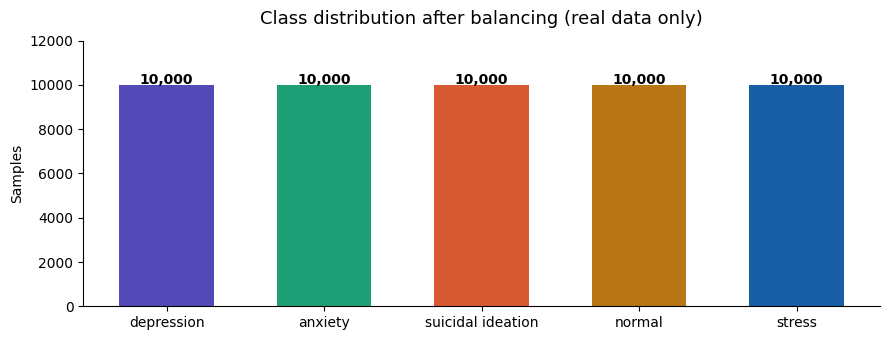

In [6]:
def balance_classes(df, target_n=TARGET_N, seed=SEED):
    balanced = []
    for lbl in sorted(df["label"].unique()):
        subset  = df[df["label"] == lbl]
        n_avail = len(subset)
        if n_avail == 0:
            print(f"  [ERROR] Label {lbl} ({CLASS_NAMES[lbl]}) has 0 rows!")
            continue
        if n_avail < target_n:
            # Upsample WITH replacement (only if class is small)
            subset = resample(subset, replace=True,
                              n_samples=target_n, random_state=seed)
            status = f"upsampled   {n_avail:>7,} → {target_n:,}"
        else:
            subset = subset.sample(n=target_n, random_state=seed)
            status = f"downsampled {n_avail:>7,} → {target_n:,}"
        print(f"  {CLASS_NAMES[lbl]:22s}: {status}")
        balanced.append(subset)

    return (pd.concat(balanced)
              .sample(frac=1, random_state=seed)
              .reset_index(drop=True))

print("Balancing classes ...")
df = balance_classes(df_all)
print(f"\n✓ Final balanced dataset: {len(df):,} rows — ALL REAL DATA")

# ── Bar chart ────────────────────────────────────────────────
colors = ["#534AB7","#1D9E75","#D85A30","#BA7517","#185FA5"]
fig, ax = plt.subplots(figsize=(9,3.5))
counts = df["label"].value_counts().sort_index()
bars = ax.bar(CLASS_NAMES, counts.values, color=colors, width=0.6)
for bar, v in zip(bars, counts.values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+40,
            f"{v:,}", ha="center", fontsize=10, fontweight="bold")
ax.set_title("Class distribution after balancing (real data only)", fontsize=13, pad=12)
ax.set_ylabel("Samples"); ax.set_ylim(0, TARGET_N*1.2)
ax.spines[["top","right"]].set_visible(False)
plt.tight_layout(); plt.show()

###6.Add Auxiliary Features

Alongside the raw text, we give the model three extra numeric clues:



**sentiment:**  VADER score: −1 (very negative) → +1 (very positive)

**text_length:** Number of words in the post

**neg_count:** How many hopeless/crisis keywords appear


These help the model catch cases where the wording is subtle but the sentiment is clear.

Computing auxiliary features (~45s)...
✓ Done
       sentiment  text_length  neg_count
count  50000.000    50000.000  50000.000
mean      -0.313       94.825      0.515
std        0.637      141.410      0.813
min       -1.000        8.000      0.000
25%       -0.875       23.000      0.000
50%       -0.554       40.000      0.000
75%        0.178      108.000      1.000
max        1.000     5255.000      8.000


/tmp/ipykernel_2926/3235685735.py:17: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_by_class, patch_artist=True, labels=CLASS_NAMES, widths=0.5)


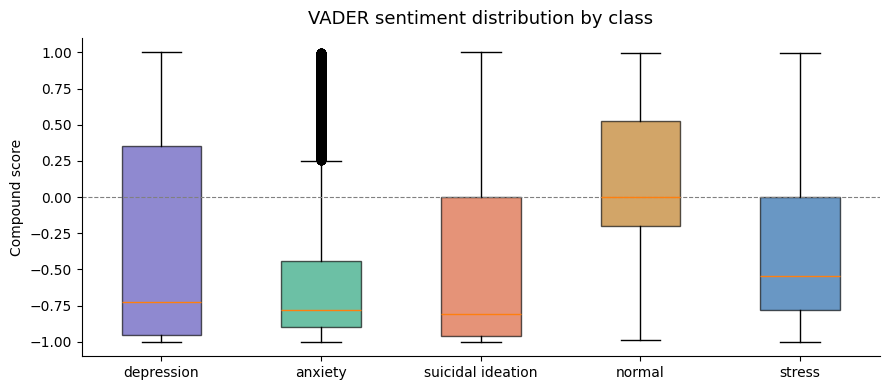

In [7]:
# VADER = Valence Aware Dictionary and sEntiment Reasoner
# It's a fast, rule-based tool — no training required
analyzer = SentimentIntensityAnalyzer()
NEG_KEYWORDS = [
    "never","can't","cannot","hopeless","worthless","empty","numb",
    "pointless","meaningless","give up","no hope","tired of",
    "no reason","hate myself","end it","can't go on"
]

print("Computing auxiliary features (~45s)...")
# sentiment: compound score from VADER (-1 to +1)
df["sentiment"]   = df["text"].apply(lambda x: analyzer.polarity_scores(x)["compound"])

# text_length: number of words (longer posts sometimes signal more distress)
df["text_length"] = df["text"].str.split().str.len()
# neg_count: simple keyword match — how many crisis phrases appear in the post
df["neg_count"]   = df["text"].apply(lambda x: sum(k in x.lower() for k in NEG_KEYWORDS))
print("✓ Done")
print(df[["sentiment","text_length","neg_count"]].describe().round(3))
# ── Plot sentiment distribution per class ─────────────────────────────
fig, ax = plt.subplots(figsize=(9,4))
data_by_class = [df[df["label"]==i]["sentiment"].values for i in range(NUM_CLASSES)]
bp = ax.boxplot(data_by_class, patch_artist=True, labels=CLASS_NAMES, widths=0.5)
for patch, c in zip(bp["boxes"], colors):
    patch.set_facecolor(c); patch.set_alpha(0.65)
ax.axhline(0, color="gray", linestyle="--", lw=0.8)
ax.set_title("VADER sentiment distribution by class", fontsize=13, pad=10)
ax.set_ylabel("Compound score")
ax.spines[["top","right"]].set_visible(False)
plt.tight_layout(); plt.show()

### 7.Split Data into Train / Validation / Test
We divide the data into three non-overlapping buckets:

Split	Size	Purpose
Train	80%	The model learns from this
Validation	10%	We check performance during training to catch overfitting
Test	10%	Final honest evaluation  the model never sees this during training
stratify=df["label"] ensures each split has the same class ratio.

In [9]:
# First split: 80% train, 20% temp
df_train, df_temp = train_test_split(df, test_size=0.20, stratify=df["label"], random_state=SEED)
# Second split: split the 20% temp into 10% val and 10% test
df_val,   df_test  = train_test_split(df_temp, test_size=0.50, stratify=df_temp["label"], random_state=SEED)
print(f"✓ Split — Train: {len(df_train):,}  Val: {len(df_val):,}  Test: {len(df_test):,}")
print("\nTrain class distribution:")
print(df_train["label"].value_counts().sort_index()
      .rename(index={i:n for i,n in enumerate(CLASS_NAMES)}))

✓ Split — Train: 40,000  Val: 5,000  Test: 5,000

Train class distribution:
label
depression           8000
anxiety              8000
suicidal ideation    8000
normal               8000
stress               8000
Name: count, dtype: int64


### 8.Tokenise Text & Build DataLoaders
The model can't read raw text it needs numbers. The tokeniser converts each post into a list of token IDs that RoBERTa understands.

We use mental/mental-roberta-base, which is RoBERTa fine-tuned on mental health text it understands words like "hopeless" or "panic attack" much better than a general tokeniser.

A DataLoader then wraps everything into efficient batches ready for training.

In [ ]:
tokenizer = RobertaTokenizer.from_pretrained("roberta-base")

class MindLensDataset(Dataset):
    """
    Per-sample dict:
      input_ids      (128,)  — RoBERTa token ids
      attention_mask (128,)  — padding mask
      aux_features   (3,)    — [sentiment, length_norm, neg_norm]
      label          scalar  — int64 class index 0-4
    """
    def __init__(self, df, tokenizer, max_len=MAX_LEN):
        self.texts      = df["text"].tolist()
        self.labels     = df["label"].tolist()
        self.sentiments = df["sentiment"].tolist()
        self.lengths    = (df["text_length"] / 512).clip(0,1).tolist()
        self.negcounts  = (df["neg_count"]   / 10 ).clip(0,1).tolist()
        self.tokenizer  = tokenizer
        self.max_len    = max_len

    def __len__(self): return len(self.texts)

    def __getitem__(self, idx):
        enc = self.tokenizer(
            self.texts[idx], max_length=self.max_len,
            padding="max_length", truncation=True, return_tensors="pt"
        )
        return {
            "input_ids":      enc["input_ids"].squeeze(0),
            "attention_mask": enc["attention_mask"].squeeze(0),
            "aux_features":   torch.tensor([self.sentiments[idx],
                                            self.lengths[idx],
                                            self.negcounts[idx]], dtype=torch.float),
            "label":          torch.tensor(self.labels[idx], dtype=torch.long),
        }

train_dataset = MindLensDataset(df_train, tokenizer)
val_dataset   = MindLensDataset(df_val,   tokenizer)
test_dataset  = MindLensDataset(df_test,  tokenizer)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)

print("✓ Tokeniser + DataLoaders ready")
print(f"  Train batches: {len(train_loader)}  |  Val: {len(val_loader)}  |  Test: {len(test_loader)}")

batch = next(iter(train_loader))
print(f"\n✓ Sample batch:")
print(f"  input_ids      : {batch['input_ids'].shape}")
print(f"  attention_mask : {batch['attention_mask'].shape}")
print(f"  aux_features   : {batch['aux_features'].shape}")
print(f"  labels         : {batch['label'].shape}  unique={sorted(batch['label'].unique().tolist())}")

✓ Tokeniser + DataLoaders ready
  Train batches: 1250  |  Val: 157  |  Test: 157

✓ Sample batch:
  input_ids      : torch.Size([32, 128])
  attention_mask : torch.Size([32, 128])
  aux_features   : torch.Size([32, 3])
  labels         : torch.Size([32])  unique=[0, 1, 2, 3, 4]


/opt/anaconda3/lib/python3.13/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


In [ ]:
import sys
!{sys.executable} -m pip install transformers torch scikit-learn shap matplotlib seaborn --quiet
print("Done")

Done


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from transformers import RobertaTokenizer, RobertaModel, get_linear_schedule_with_warmup
from torch.optim import AdamW
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import warnings
warnings.filterwarnings("ignore")

if torch.cuda.is_available():
    DEVICE = torch.device("cuda")
elif torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
else:
    DEVICE = torch.device("cpu")
print(f"Device: {DEVICE}")
if DEVICE.type == "cuda":
    print(f"  GPU  : {torch.cuda.get_device_name(0)}")
    print(f"  VRAM : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB")
elif DEVICE.type == "mps":
    print("  GPU  : Apple M-series (MPS)")
    print("  Note : MPS does not report VRAM separately")

Device: mps
  GPU  : Apple M-series (MPS)
  Note : MPS does not report VRAM separately


In [ ]:
from torch.utils.data import Dataset, DataLoader

MAX_LEN    = 256
BATCH_SIZE = 16
SEED       = 42

print("Loading mental/mental-roberta-base tokeniser...")
tokenizer = RobertaTokenizer.from_pretrained("mental/mental-roberta-base")
print(f"Tokeniser ready  |  max_len={MAX_LEN}  batch_size={BATCH_SIZE}")

class MindLensDataset(Dataset):
    def __init__(self, df, tokenizer, max_len=MAX_LEN):
        self.texts      = df["text"].tolist()
        self.labels     = df["label"].tolist()
        self.sentiments = df["sentiment"].tolist()
        # Normalise length to 0–1 range (cap at 512 words)
        self.lengths    = (df["text_length"] / 512).clip(0, 1).tolist()
        # Normalise neg_count to 0–1 range (cap at 10 keywords)
        self.negcounts  = (df["neg_count"]   / 10 ).clip(0, 1).tolist()
        self.tokenizer  = tokenizer
        self.max_len    = max_len

    def __len__(self):
        return len(self.texts) # Total number of samples

    def __getitem__(self, idx):
      # Tokenise a single post
        enc = self.tokenizer(
            self.texts[idx],
            max_length=self.max_len,
            padding="max_length", # Pad shorter posts with zeros
            truncation=True, # Cut posts longer than max_len
            return_tensors="pt",
        )
        return {
            "input_ids":      enc["input_ids"].squeeze(0),
            "attention_mask": enc["attention_mask"].squeeze(0),
            "aux_features":   torch.tensor([self.sentiments[idx],
                                            self.lengths[idx],
                                            self.negcounts[idx]], dtype=torch.float),
            "label":          torch.tensor(self.labels[idx], dtype=torch.long),
        }
# Build dataset objects for each split
train_dataset = MindLensDataset(df_train, tokenizer)
val_dataset   = MindLensDataset(df_val,   tokenizer)
test_dataset  = MindLensDataset(df_test,  tokenizer)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)

print(f"DataLoaders ready  |  train={len(train_loader)} val={len(val_loader)} test={len(test_loader)} batches")

Loading mental/mental-roberta-base tokeniser...
Tokeniser ready  |  max_len=256  batch_size=16
DataLoaders ready  |  train=2500 val=313 test=313 batches


## 9. Focal Loss (Smarter Training Signal)
Standard cross-entropy loss treats every mistake equally. Focal Loss is smarter,  it focuses more training effort on the hard examples (the ones the model keeps getting wrong) and reduces the impact of easy examples the model already handles well.

We also add label smoothing (0.1) to prevent the model from becoming overconfident.

In [ ]:
class FocalLoss(nn.Module):
    def __init__(self, gamma=2.0, alpha=None, label_smoothing=0.1, reduction="mean"):
        super().__init__()
        self.gamma           = gamma
        self.alpha           = alpha
        self.label_smoothing = label_smoothing
        self.reduction       = reduction

    def forward(self, logits, targets):
      # Standard cross-entropy, but keep per-sample losses (reduction="none")
        ce_loss = F.cross_entropy(
            logits, targets,
            weight=self.alpha,
            label_smoothing=self.label_smoothing,
            reduction="none"
        )
        pt = torch.exp(-ce_loss) # Probability of the correct class
        fl = (1 - pt) ** self.gamma * ce_loss # Penalise easy examples less
        return fl.mean() if self.reduction == "mean" else fl.sum()
# Compute inverse-frequency class weights so rarer classes get more attention
label_counts  = torch.tensor(
    [len(df_train[df_train["label"] == i]) for i in range(NUM_CLASSES)],
    dtype=torch.float
)
class_weights = (1.0 / label_counts)
class_weights = (class_weights / class_weights.sum() * NUM_CLASSES).to(DEVICE)

criterion = FocalLoss(gamma=2.0, alpha=class_weights, label_smoothing=0.1)
print("Focal Loss ready  |  gamma=2  label_smoothing=0.1")
print(f"Class weights: {class_weights.cpu().numpy().round(4)}")

Focal Loss ready  |  gamma=2  label_smoothing=0.1
Class weights: [1. 1. 1. 1. 1.]


##10. Build the MindLens Model
The model has two parts working together:

**mental/mental-roberta-base** : A large pre-trained language model that reads the text and produces a 768-dimensional vector summarising its meaning (the [CLS] token).

**Classification head** : A small neural network on top that takes the 768-dim vector + 3 auxiliary features and outputs 5 class probabilities.

We use dropout (randomly switching off neurons during training) to prevent overfitting.

In [ ]:

class MindLensModel(nn.Module):
    def __init__(self, num_classes=NUM_CLASSES, dropout=0.4):
        super().__init__()
        # Load mental-health-specific RoBERTa (better than generic roberta-base for this task)
        self.roberta = RobertaModel.from_pretrained("mental/mental-roberta-base")
        hidden       = self.roberta.config.hidden_size
        # Normalise the combined vector before passing to the classifier
        self.norm    = nn.LayerNorm(hidden + 3) # +3 for aux features
        self.drop1   = nn.Dropout(dropout) # 0.4 — heavier regularisation early
        self.fc1     = nn.Linear(hidden + 3, 256)
        self.drop2   = nn.Dropout(0.3)  # 0.3 — lighter regularisation near output
        self.fc2     = nn.Linear(256, num_classes)

    def forward(self, input_ids, attention_mask, aux_features):
      # Run text through RoBERTa
        out      = self.roberta(input_ids=input_ids, attention_mask=attention_mask)
        cls_out  = out.last_hidden_state[:, 0, :]
        # Fuse text representation with auxiliary features
        combined = torch.cat([cls_out, aux_features], dim=1)
        #classify
        x        = self.norm(combined)
        x        = self.drop1(x)
        x        = F.gelu(self.fc1(x))# GELU is smoother than ReLU — works better with transformers
        x        = self.drop2(x)
        return self.fc2(x) # Raw logits (not probabilities yet)

model = MindLensModel(num_classes=NUM_CLASSES).to(DEVICE)
total     = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Model ready  |  total={total:,}  trainable={trainable:,}")
print(f"Base: mental/mental-roberta-base  |  dropout: 0.4/0.3")

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: mental/mental-roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.bias              | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
pooler.dense.weight             | MISSING    | 
pooler.dense.bias               | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model ready  |  total=124,846,091  trainable=124,846,091
Base: mental/mental-roberta-base  |  dropout: 0.4/0.3


## 11. Freeze RoBERTa Layers (Staged Fine-tuning)

RoBERTa has **12 transformer layers**. Training all of them from the start is risky, they might "forget" what they learned during pre-training (called *catastrophic forgetting*).

Instead we use **staged fine-tuning**:
1. **Epochs 1–2**: Only the classification head trains. RoBERTa layers are frozen.
2. **Epoch 3 onwards**: We gradually unfreeze the last few RoBERTa layers, letting them also adapt to mental health text.

This is like warming up before a workout, you don't start with heavy weights.


In [ ]:
def set_roberta_layers_frozen(model, frozen: bool, up_to_layer: int = 11):
    for i, layer in enumerate(model.roberta.encoder.layer):
        if i <= up_to_layer:
            for param in layer.parameters():
                param.requires_grad = not frozen
    n_trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    status = "FROZEN" if frozen else "UNFROZEN"
    print(f"  Layers 0-{up_to_layer}: {status}  |  trainable params: {n_trainable:,}")

# Freeze ALL 12 layers — only train the head
print("Freezing ALL RoBERTa layers (train head only):")
set_roberta_layers_frozen(model, frozen=True, up_to_layer=9)
# Freezes layers 0-9, leaves 10-11 to be trained from epoch 1

Freezing ALL RoBERTa layers (train head only):
  Layers 0-9: FROZEN  |  trainable params: 53,967,371


##  12. Optimiser & Learning Rate Scheduler

We use **AdamW** with two different learning rates:
- **RoBERTa layers**: very small LR (`1e-5`):  I don't want to undo their pre-training
- **Classification head**: larger LR (`5e-5`):  this part is learning from scratch

The **linear schedule with warmup** starts the LR very low, ramps it up over the first 15% of training steps, then gradually decreases it. This prevents the model from making wild updates early on.


In [ ]:
EPOCHS       = 15 # Maximum training rounds (early stopping may cut this short)
LR_ROBERTA   = 1e-5 # Learning rate for pre-trained RoBERTa layers (very conservative)
LR_HEAD      = 5e-5    # Learning rate for our custom classification head
WARMUP_RATIO = 0.15    # Fraction of total steps used for warm-up
# Separate the parameters into two groups with different learning rates
roberta_params = [p for n, p in model.named_parameters() if "roberta" in n and p.requires_grad]
head_params    = [p for n, p in model.named_parameters() if "roberta" not in n and p.requires_grad]

optimizer = AdamW(
    [{"params": roberta_params, "lr": LR_ROBERTA},
     {"params": head_params,    "lr": LR_HEAD}],
    weight_decay=0.01, # L2 regularisation — penalises very large weights
)

total_steps  = len(train_loader) * EPOCHS
warmup_steps = int(total_steps * WARMUP_RATIO)
scheduler    = get_linear_schedule_with_warmup(optimizer,
               num_warmup_steps=warmup_steps, num_training_steps=total_steps)

print(f"Optimiser ready")
print(f"  LR RoBERTa={LR_ROBERTA}  LR head={LR_HEAD}  warmup={warmup_steps:,}/{total_steps:,} steps")

Optimiser ready
  LR RoBERTa=1e-05  LR head=5e-05  warmup=5,625/37,500 steps


##  13. Training & Evaluation Functions

Two helper functions: one for training a single epoch, one for evaluating:

- **`train_epoch`**: Runs all training batches, updates weights, returns loss + accuracy.
- **`eval_epoch`**: Runs batches in inference mode (no gradient updates), returns loss, accuracy, and F1 score.

`clip_grad_norm_` is a safety measure that prevents any single gradient update from being too large (which would destabilise training).


In [ ]:
def train_epoch(model, loader, optimizer, scheduler, criterion, device):
    model.train() # Sets dropout layers to active (training mode)
    total_loss, all_preds, all_labels = 0.0, [], []
    for batch in loader:
        ids  = batch["input_ids"].to(device)
        mask = batch["attention_mask"].to(device)
        aux  = batch["aux_features"].to(device)
        lbls = batch["label"].to(device)
        optimizer.zero_grad() # Clear gradients from previous step
        logits = model(ids, mask, aux)
        loss   = criterion(logits, lbls)
        loss.backward()
        # Clip gradients: prevents any single update from being too large
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        scheduler.step()
        total_loss += loss.item()
        all_preds.extend(logits.argmax(-1).cpu().numpy())
        all_labels.extend(lbls.cpu().numpy())
    return total_loss / len(loader), accuracy_score(all_labels, all_preds)


def eval_epoch(model, loader, criterion, device):
    model.eval()
    total_loss, all_preds, all_labels = 0.0, [], []
    with torch.no_grad():
        for batch in loader:
            ids  = batch["input_ids"].to(device)
            mask = batch["attention_mask"].to(device)
            aux  = batch["aux_features"].to(device)
            lbls = batch["label"].to(device)
            logits = model(ids, mask, aux)
            loss   = criterion(logits, lbls)
            total_loss += loss.item()
            all_preds.extend(logits.argmax(-1).cpu().numpy())
            all_labels.extend(lbls.cpu().numpy())
    acc = accuracy_score(all_labels, all_preds)
    f1  = f1_score(all_labels, all_preds, average="macro")
    return total_loss / len(loader), acc, f1, all_preds, all_labels

print("Train/eval functions ready")

Train/eval functions ready


## 14. Training Loop

This is where the model actually learns. Each **epoch** is one full pass through the training data.

Key features:
- **Early stopping** (patience=5): If validation accuracy doesn't improve for 5 epochs in a row, we stop early to avoid overfitting.
- **Best model checkpointing**: Every time validation accuracy improves, we save a copy of the model weights.
- **Layer unfreezing at epoch 3**: The last 4 RoBERTa layers (8–11) become trainable.


In [ ]:
history = {"train_loss":[], "train_acc":[], "val_loss":[], "val_acc":[], "val_f1":[]}

best_val_acc    = 0.0
patience        = 5
patience_ctr    = 0
UNFREEZE_EPOCH  = 3
import os
best_model_path = os.path.join(os.getcwd(), "mindlens_best_v2.pt")

print(f"Training up to {EPOCHS} epochs  |  patience={patience}  unfreeze at epoch {UNFREEZE_EPOCH}")
print("=" * 72)

for epoch in range(1, EPOCHS + 1):

    if epoch == UNFREEZE_EPOCH:
        print(f"  Unfreezing last 2 RoBERTa layers (10-11) from epoch {epoch}:")
        for i, layer in enumerate(model.roberta.encoder.layer):
            if i >= 8:    # layers 8, 9, 10, 11
                for param in layer.parameters():
                    param.requires_grad = True
        n_trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
        print(f"  Trainable params: {n_trainable:,}")
        roberta_params = [p for n, p in model.named_parameters()
                          if "roberta" in n and p.requires_grad]
        head_params    = [p for n, p in model.named_parameters()
                          if "roberta" not in n and p.requires_grad]
        optimizer = AdamW(
            [{"params": roberta_params, "lr": LR_ROBERTA},
             {"params": head_params,    "lr": LR_HEAD}],
            weight_decay=0.01,
        )

    train_loss, train_acc = train_epoch(model, train_loader, optimizer, scheduler, criterion, DEVICE)
    val_loss, val_acc, val_f1, _, _ = eval_epoch(model, val_loader, criterion, DEVICE)

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)
    history["val_f1"].append(val_f1)

    gap    = train_acc - val_acc
    marker = ""
    # ── Save best model checkpoint ────────────────────────────────────
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), best_model_path)
        patience_ctr = 0
        marker = "  <- best"
    else:
        patience_ctr += 1

    print(f"Epoch {epoch:2d}/{EPOCHS}  "
          f"train loss:{train_loss:.4f} acc:{train_acc:.4f}  "
          f"val loss:{val_loss:.4f} acc:{val_acc:.4f} F1:{val_f1:.4f}  "
          f"gap:{gap:+.3f}{marker}")

    if patience_ctr >= patience:
        print(f"\nEarly stopping at epoch {epoch}.")
        break

print(f"\nBest val accuracy: {best_val_acc:.4f}  ({best_val_acc*100:.2f}%)")

Training up to 15 epochs  |  patience=5  unfreeze at epoch 3
Epoch  1/15  train loss:0.6144 acc:0.5843  val loss:0.2627 acc:0.8388 F1:0.8390  gap:-0.255  <- best
Epoch  2/15  train loss:0.2540 acc:0.8349  val loss:0.2196 acc:0.8590 F1:0.8581  gap:-0.024  <- best
  Unfreezing last 2 RoBERTa layers (10-11) from epoch 3:
  Trainable params: 68,143,115
Epoch  3/15  train loss:0.2171 acc:0.8598  val loss:0.1981 acc:0.8662 F1:0.8645  gap:-0.006  <- best
Epoch  4/15  train loss:0.1894 acc:0.8805  val loss:0.1963 acc:0.8746 F1:0.8724  gap:+0.006  <- best
Epoch  5/15  train loss:0.1714 acc:0.8927  val loss:0.1920 acc:0.8832 F1:0.8822  gap:+0.010  <- best
Epoch  6/15  train loss:0.1564 acc:0.9060  val loss:0.1875 acc:0.8896 F1:0.8894  gap:+0.016  <- best
Epoch  7/15  train loss:0.1433 acc:0.9163  val loss:0.1886 acc:0.8812 F1:0.8806  gap:+0.035
Epoch  8/15  train loss:0.1310 acc:0.9287  val loss:0.2068 acc:0.8868 F1:0.8866  gap:+0.042
Epoch  9/15  train loss:0.1195 acc:0.9415  val loss:0.2443 ac

## 15. Plot Training Curves

Three charts to help you understand how training went:
- **Loss**: Should decrease over time for both train and val
- **Accuracy**: Should increase. If train >> val, the model is overfitting
- **Val Macro-F1**: The most reliable single metric for imbalanced classification


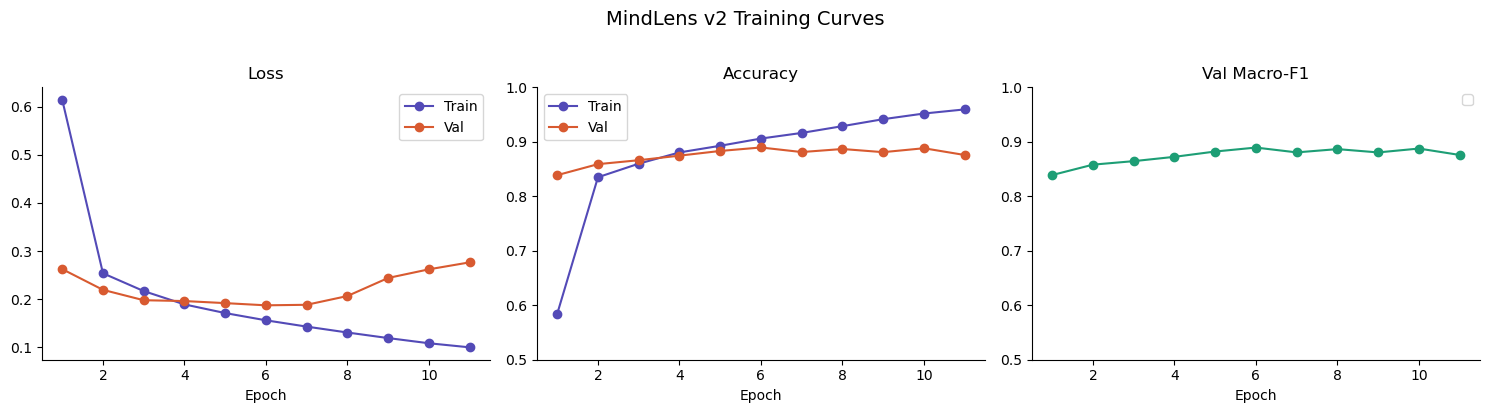

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
ep = range(1, len(history["train_loss"]) + 1)
# Loss chart
axes[0].plot(ep, history["train_loss"], "o-", label="Train", color="#534AB7")
axes[0].plot(ep, history["val_loss"],   "o-", label="Val",   color="#D85A30")
axes[0].set_title("Loss"); axes[0].set_xlabel("Epoch"); axes[0].legend()
axes[0].spines[["top","right"]].set_visible(False)
# Accuracy chart
axes[1].plot(ep, history["train_acc"], "o-", label="Train", color="#534AB7")
axes[1].plot(ep, history["val_acc"],   "o-", label="Val",   color="#D85A30")
axes[1].set_title("Accuracy"); axes[1].set_xlabel("Epoch")
axes[1].set_ylim(0.5, 1.0); axes[1].legend()
axes[1].spines[["top","right"]].set_visible(False)
# Macro-F1 chart (best single number for multi-class performance)
axes[2].plot(ep, history["val_f1"], "o-", color="#1D9E75")
axes[2].set_title("Val Macro-F1"); axes[2].set_xlabel("Epoch")
axes[2].set_ylim(0.5, 1.0); axes[2].legend()
axes[2].spines[["top","right"]].set_visible(False)

plt.suptitle("MindLens v2 Training Curves", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig("training_curves_v2.png", dpi=150, bbox_inches="tight")
plt.show()

## 16. Final Test Evaluation

Load the **best checkpoint** (saved during training) and run it on the test set  data the model has never seen before. This is the honest score.

The **classification report** shows precision, recall, and F1 for each class individually. Pay special attention to `suicidal ideation` , false negatives there are the most critical.


In [ ]:
# Load the best weights (from the epoch with highest validation accuracy)
model.load_state_dict(torch.load(best_model_path, map_location=DEVICE, weights_only=False))
test_loss, test_acc, test_f1, test_preds, test_labels = eval_epoch(
    model, test_loader, criterion, DEVICE)

print(f"{'='*55}")
print(f"  MINDLENS v2 - TEST RESULTS")
print(f"{'='*55}")
print(f"  Accuracy : {test_acc:.4f}  ({test_acc*100:.2f}%)")
print(f"  Macro F1 : {test_f1:.4f}")
print(f"  Loss     : {test_loss:.4f}")
print(f"{'='*55}")
print()
# Full per-class breakdown: precision, recall, F1, support

print(classification_report(test_labels, test_preds, target_names=CLASS_NAMES, digits=4))

  MINDLENS v2 - TEST RESULTS
  Accuracy : 0.8900  (89.00%)
  Macro F1 : 0.8900
  Loss     : 0.1953

                   precision    recall  f1-score   support

       depression     0.7960    0.7570    0.7760      1000
          anxiety     0.9578    0.9770    0.9673      1000
suicidal ideation     0.7737    0.8170    0.7947      1000
           normal     0.9532    0.9580    0.9556      1000
           stress     0.9721    0.9410    0.9563      1000

         accuracy                         0.8900      5000
        macro avg     0.8906    0.8900    0.8900      5000
     weighted avg     0.8906    0.8900    0.8900      5000



## 17.  Confusion Matrix

A confusion matrix shows which classes the model mixes up.

- **Left chart**: Raw counts: how many samples of each true class were predicted as each class
- **Right chart**: Normalised (0–1): easier to compare across classes of different sizes

Look at the diagonal, those are correct predictions. Off-diagonal entries are mistakes.


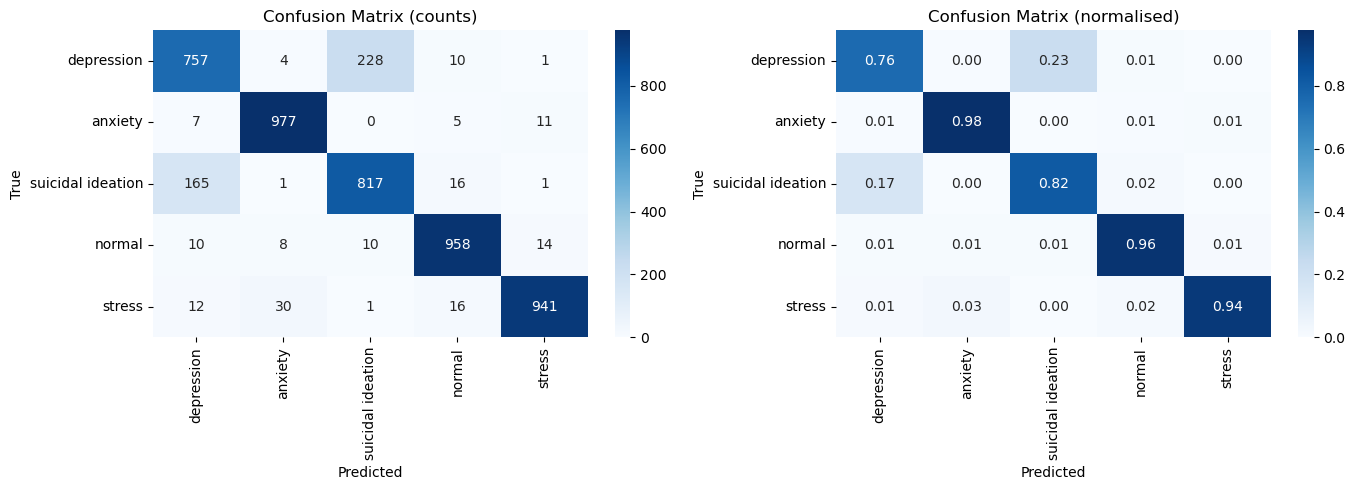

In [ ]:
cm      = confusion_matrix(test_labels, test_preds)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
# Raw count heatmap
sns.heatmap(cm,      annot=True, fmt="d",   cmap="Blues",
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=axes[0])
axes[0].set_title("Confusion Matrix (counts)")
axes[0].set_ylabel("True"); axes[0].set_xlabel("Predicted")

# Normalised heatmap (fraction of each true class correctly/incorrectly classified)
sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="Blues",
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=axes[1])
axes[1].set_title("Confusion Matrix (normalised)")
axes[1].set_ylabel("True"); axes[1].set_xlabel("Predicted")

plt.tight_layout()
plt.savefig(os.path.join(os.getcwd(), "confusion_matrix_v2.png"), dpi=150, bbox_inches="tight")
plt.show()

##18. SHAP Explainability

**SHAP** (SHapley Additive exPlanations) answers the question:  
*"Which words pushed the model towards this prediction?"*

This is crucial for a mental health tool you need to know *why* the model said "suicidal ideation" and not just that it did.



Computing SHAP values for 4 samples...


  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer:  25%|█████▊                 | 1/4 [00:00<?, ?it/s]

  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer:  75%|███████████▎   | 3/4 [00:28<00:06,  6.57s/it]

  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer: 100%|███████████████| 4/4 [00:42<00:00,  9.50s/it]

  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer: 5it [00:56, 14.12s/it]                            

SHAP ready


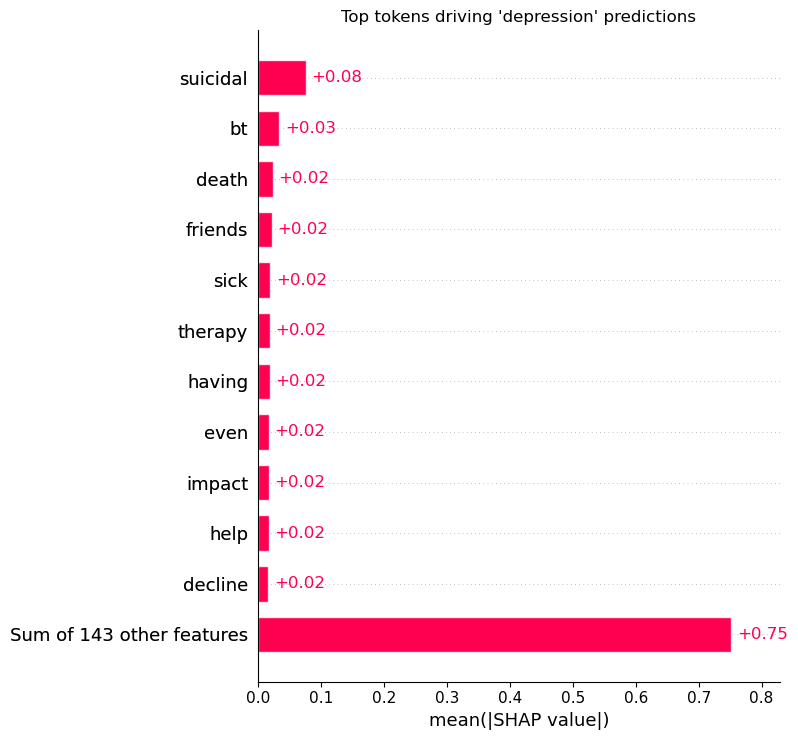

In [ ]:
class MindLensPipeline:
    def __call__(self, texts):

        model.float()


        if isinstance(texts, list) and len(texts) > 0 and isinstance(texts[0], str):
            pass  # texts is already in the correct format
        elif isinstance(texts, str):
            texts = [texts]
        else:
            # Convert other formats to strings if needed
            texts = [str(text) for text in texts]

        enc = tokenizer(texts, max_length=MAX_LEN, padding="max_length",
                        truncation=True, return_tensors="pt").to(DEVICE)

        # Auxiliary features set to zero for SHAP (we want token-level attributions only)
        aux = torch.zeros(len(texts), 3).to(DEVICE)
        with torch.no_grad():
            logits = model(enc["input_ids"], enc["attention_mask"], aux)
            return torch.softmax(logits, dim=-1).cpu().numpy()

pipe      = MindLensPipeline()
masker    = shap.maskers.Text(tokenizer) # Masker replaces tokens with [MASK] to measure impact
explainer = shap.Explainer(pipe, masker, output_names=CLASS_NAMES)
# Pick one example per class from the test set
sample_texts = []
for cls in range(NUM_CLASSES):
    idx = next(i for i, l in enumerate(test_labels) if l == cls)
    sample_texts.append(df_test.iloc[idx]["text"][:300])

print("Computing SHAP values for 4 samples...")
shap_values = explainer(sample_texts[:4])
print("SHAP ready")
# Bar chart: which tokens most influenced "depression" predictions?
shap.plots.bar(shap_values[:, :, CLASS_NAMES[0]], max_display=12, show=False)
plt.title(f"Top tokens driving '{CLASS_NAMES[0]}' predictions")
plt.tight_layout()
plt.savefig("shap_v2.png", dpi=150, bbox_inches="tight")
plt.show()

##19. Save the Model

Save everything needed to reload and use MindLens later:



In [ ]:
import os, json
SAVE_DIR = os.path.join(os.getcwd(), "mindlens_model")
os.makedirs(SAVE_DIR, exist_ok=True)

torch.save(model.state_dict(), f"{SAVE_DIR}/mindlens_roberta.pt")
tokenizer.save_pretrained(f"{SAVE_DIR}/tokenizer")
with open(f"{SAVE_DIR}/label_map.json", "w") as f:
    json.dump({
        "id2label"   : {str(i): n for i, n in enumerate(CLASS_NAMES)},
        "label2id"   : {n: i for i, n in enumerate(CLASS_NAMES)},
        "num_classes": NUM_CLASSES,
        "model_base" : "mental/mental-roberta-base",
        "max_len"    : MAX_LEN,
        "test_acc"   : round(test_acc, 4),
        "test_f1"    : round(test_f1, 4),
    }, f, indent=2)

print(f"Saved to {SAVE_DIR}/")

print(f"Model files saved locally to: {SAVE_DIR}/")
print("No download needed — files are already on your Mac.")

Saved to /Users/helikuvadiya/Downloads/mindlens_model/
Model files saved locally to: /Users/helikuvadiya/Downloads/mindlens_model/
No download needed — files are already on your Mac.


## 20. Quick Inference Demo

Try the model on a few example posts to see it in action.  
The `predict()` function takes any text string and returns the predicted class + confidence + full probability breakdown.


In [ ]:
def predict(text: str):
    model.eval()
    enc = tokenizer(text, max_length=MAX_LEN, padding="max_length",
                    truncation=True, return_tensors="pt").to(DEVICE)
    aux = torch.zeros(1, 3).to(DEVICE)
    with torch.no_grad():
        logits = model(enc["input_ids"], enc["attention_mask"], aux)
        probs  = torch.softmax(logits, dim=-1).squeeze().cpu().numpy()
    pred_id = int(probs.argmax())
    return {
        "prediction"    : CLASS_NAMES[pred_id],
        "confidence"    : round(float(probs[pred_id]), 4),
        "probabilities" : {c: round(float(p), 4) for c, p in zip(CLASS_NAMES, probs)},
    }

posts = [
    "I have not been able to get out of bed for three days. Everything feels pointless.",
    "My heart races every time I think about the presentation. I cannot stop worrying.",
    "I keep reliving the accident over and over. Loud noises make me completely freeze.",
    "There is no reason to keep going. I am a burden to everyone around me.",
    "Had a productive day today, feeling good about the progress I made this week.",
]
print("Inference Demo - MindLens v2")
print("=" * 55)
for post in posts:
    r = predict(post)
    print(f"\nText       : {post[:65]}...")
    print(f"Prediction : {r['prediction'].upper():<22} confidence: {r['confidence']:.2%}")
    for cls, prob in r["probabilities"].items():
        bar = "X" * int(prob * 25)
        print(f"  {cls:<22}: {prob:.3f}  {bar}")

Inference Demo - MindLens v2

Text       : I have not been able to get out of bed for three days. Everything...
Prediction : DEPRESSION             confidence: 73.87%
  depression            : 0.739  XXXXXXXXXXXXXXXXXX
  anxiety               : 0.017  
  suicidal ideation     : 0.210  XXXXX
  normal                : 0.018  
  stress                : 0.016  

Text       : My heart races every time I think about the presentation. I canno...
Prediction : ANXIETY                confidence: 93.55%
  depression            : 0.017  
  anxiety               : 0.935  XXXXXXXXXXXXXXXXXXXXXXX
  suicidal ideation     : 0.019  
  normal                : 0.016  
  stress                : 0.013  

Text       : I keep reliving the accident over and over. Loud noises make me c...
Prediction : DEPRESSION             confidence: 32.09%
  depression            : 0.321  XXXXXXXX
  anxiety               : 0.204  XXXXX
  suicidal ideation     : 0.281  XXXXXXX
  normal                : 0.054  X
  stress      

In [ ]:

import torch

torch.save(model.state_dict(), "mindlens_model/model.pth")
print("✅ Model weights saved")
